# Lab 1: Repair a Sentinel discovery service

Real data repair edition · v3.0 · 5 October 2026

Automated Workflows in Satellite Image Processing · AGH

You have inherited a small prototype. It handles a simple demonstration, but its database cannot grow with the pipeline, its catalogue reader misses pages, and its progress tracking loses late arrivals and advances too early.

Your job is to diagnose and repair these behaviours. There are three exercises. Every editable function already contains working code. Keep the supplied function names and arguments so the checks and live demonstration can use your repairs.

Use real Sentinel 2 catalog records and a real JPEG from the start. A captured copy is embedded for repeatable checks; live catalog discovery and one preview transfer are enabled for the final integration. No Gaia access or account is needed. The safe downloader is supplied rather than assigned as a fourth exercise.

| Time in a 120 minute lab | Activity |
|---|---|
| 0–15 min | Inspect an item and run the prototype |
| 15–45 min | Repair the database design |
| 45–65 min | Repair pagination |
| 65–90 min | Repair discovery progress and overlap |
| 90–105 min | Verify the supplied downloader and live integration |
| 105–120 min | Explain the fixes and submit |

For a 90 minute session, shorten the discussion or move the live integration to independent work. Work in pairs if useful, but each person must explain the database relationships and restart behaviour.

For each exercise: predict a failure, run the check, inspect the evidence, make the repair, and rerun the same check. The initial `FAIL` messages are expected. Tests report behaviours, not a required coding style. Do not change checks to make a repair pass.

If you use AI, ask it to explain a failing behaviour or review your proposed change. You remain responsible for explaining the fix and the evidence.


## 1. Setup and scope

Use an existing Python 3.10+ Jupyter environment. All processing code below uses the Python standard library. If you need Jupyter, run `python -m pip install jupyterlab` and launch with `python -m jupyterlab` (each command is a single line).

Sentinel-2 is the default because this catalogue exposes public HTTPS imagery assets. An item describes one product/tile; its assets include bands and previews. A preview is one real image asset, not a complete scientific product. Later labs can select bands, read raster windows, or download full products.

Discovery can later be adapted to Sentinel-1. Do not assume its asset access rules, formats or processing requirements match Sentinel-2. Some Earth Search assets use `s3://` requester pays access; the downloader in this lab accepts HTTPS only.

The live example uses a fixed historical interval around Kraków, making a class demonstration more repeatable. Your final service will use UTC timestamps. A bounding box is `[west longitude, south latitude, east longitude, north latitude]`; a matching tile can extend far beyond it.


In [9]:
import base64
import zlib
import copy
import hashlib
import io
import json
import os
import sqlite3
import tempfile
import time
from datetime import datetime, timedelta, timezone
from pathlib import Path
from urllib.error import HTTPError, URLError
from urllib.parse import urlencode, urljoin, urlsplit
from urllib.request import Request, urlopen

ROOT = Path('sentinel_lab1_real_v3_s')
ROOT.mkdir(exist_ok=True)
DB_PATH = ROOT / 'catalogue_real_v3_s.sqlite'  # Separate from the earlier lab version.
ENDPOINT = 'https://earth-search.aws.element84.com/v1'
COLLECTION = 'sentinel-2-l2a'
BBOX = [19.7, 49.9, 20.1, 50.2]
INITIAL_START = '2025-06-01T00:00:00Z'
DEMO_END = '2025-06-15T00:00:00Z'
OVERLAP_DAYS = 3
PAGE_SIZE = 5  # Deliberately small so pagination is visible.
MAX_PAGES = 100  # Hitting this limit is an error, never a successful search.
MAX_BYTES = 5 * 1024 * 1024  # Preview cap; a whole band is normally larger.
RUN_LIVE = True  # Live metadata first; final integration waits for the repair checks.

def utc_parse(value):
    result = datetime.fromisoformat(value.replace('Z', '+00:00'))
    if result.tzinfo is None:
        raise ValueError('Use a timezone in every timestamp')
    return result.astimezone(timezone.utc)

def utc_text(value):
    return value.astimezone(timezone.utc).isoformat().replace('+00:00', 'Z')

def now_utc():
    return utc_text(datetime.now(timezone.utc))

CHECK_RESULTS = {}

def check(label, test):
    try:
        test()
    except Exception as exc:
        CHECK_RESULTS[label] = False
        print(f'FAIL: {label} — {type(exc).__name__}: {exc}')
    else:
        CHECK_RESULTS[label] = True
        print('PASS:', label)

print('Working directory:', ROOT.resolve())


Working directory: /Users/jklimek/Desktop/AGH/AUTOMATED_WORKFLOWS/Labs/sentinel_lab1_real_v3_s


## 2. Inspect real records and imagery

The embedded snapshot was retrieved from Earth Search on 5 October 2026 for Sentinel 2 L2A products over Kraków, 1–15 June 2025. It contains 16 actual items and every provider page, including the terminal empty page. IDs, acquisition times, footprints and asset URLs are preserved as returned. The embedded 33,423 byte JPEG belongs to `S2C_34UDA_20250605_0_L2A`; its source URL and SHA-256 are printed below.

The setup also requests a small live metadata page. The final integration will run your repaired discovery function against the live catalog and transfer one preview. The captured real records keep the checks independent of catalog changes and network availability.

Inspect `id`, `collection`, `properties.datetime`, `eo:cloud_cover`, and `assets`. Compare the two real tiles acquired on 4 June: do they have the same ID? Is acquisition time also catalog publication time? Why can one scene have several assets?

Some checks deliberately omit a field, hide a real item until a later replay, truncate real JPEG bytes, or inject an exception. Those are simulated conditions applied to actual source data. They do not claim that these failures or indexing delays occurred at the provider.


Captured: 16 real items on 9 provider pages
Preview: S2C_34UDA_20250605_0_L2A 33423 bytes
Preview source: https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/34/U/DA/2025/6/S2C_34UDA_20250605_0_L2A/preview.jpg
{
  "type": "Feature",
  "stac_version": "1.0.0",
  "stac_extensions": [
    "https://stac-extensions.github.io/raster/v1.1.0/schema.json",
    "https://stac-extensions.github.io/sentinel-2/v1.0.0/schema.json",
    "https://stac-extensions.github.io/mgrs/v1.0.0/schema.json",
    "https://stac-extensions.github.io/processing/v1.1.0/schema.json",
    "https://stac-extensions.github.io/grid/v1.1.0/schema.json",
    "https://stac-extensions.github.io/view/v1.0.0/schema.json",
    "https://stac-extensions.github.io/eo/v1.1.0/schema.json",
    "https://stac-extensions.github.io/projection/v1.1.0/schema.json"
  ],
  "id": "S2C_34UDA_20250602_0_L2A",
  "geometry": {
    "type": "Polygon",
    "coordinates": [
      [
        [
          19.588100514066156,
          50.

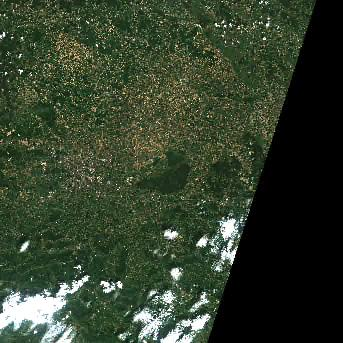

In [10]:
# Embedded real catalog and JPEG; supplied, do not edit.
SNAPSHOT_B64 = '...'
PREVIEW_B64 = '...'
PREVIEW_SHA256 = '2eb951962df7c816a24b66b48f8c66530518e191f500af1b44d0e23e7b3b61b3'

# Supplied data loading: these are captured, unmodified provider responses.
# Base64/zlib packages real bytes inside this notebook; it does not generate data.
REAL_SNAPSHOT = json.loads(zlib.decompress(base64.b64decode(SNAPSHOT_B64)))
REAL_PAGES = REAL_SNAPSHOT['pages']
REAL_URLS = REAL_SNAPSHOT['urls']
REAL_ITEMS = [item for page in REAL_PAGES for item in page['features']]
REAL_PREVIEW_BYTES = base64.b64decode(PREVIEW_B64)
assert hashlib.sha256(REAL_PREVIEW_BYTES).hexdigest() == PREVIEW_SHA256
by_id = {item['id']: item for item in REAL_ITEMS}
ITEM_A = by_id['S2C_34UDA_20250602_0_L2A']
ITEM_B = by_id['S2A_34UDA_20250604_0_L2A']
ITEM_C = by_id['S2C_34UDA_20250605_0_L2A']
LATE_ITEM = by_id['S2A_34UCA_20250604_0_L2A']
PREVIEW_ITEM = by_id[REAL_SNAPSHOT['preview_item_id']]
print('Captured:', len(REAL_ITEMS), 'real items on', len(REAL_PAGES), 'provider pages')
print('Preview:', PREVIEW_ITEM['id'], len(REAL_PREVIEW_BYTES), 'bytes')
print('Preview source:', REAL_SNAPSHOT['preview_url'])
print(json.dumps(ITEM_A, indent=2))

# A small live metadata request before the repairs: no imagery is downloaded here.
sample_url = ENDPOINT + '/search?' + urlencode({
    'collections': COLLECTION, 'bbox': ','.join(map(str, BBOX)),
    'datetime': f'{INITIAL_START}/{DEMO_END}', 'limit': PAGE_SIZE})
if RUN_LIVE:
    try:
        with urlopen(Request(sample_url, headers={'User-Agent': 'AGH-Sentinel-Lab/3.0'}), timeout=30) as response:
            sample_page = json.load(response)
        print('Live first page:', [item['id'] for item in sample_page['features']])
        print('Next link:', next((l['href'] for l in sample_page['links'] if l['rel'] == 'next'), None))
    except (URLError, TimeoutError) as exc:
        print('Live catalog unavailable; continue with the captured real records:', type(exc).__name__)
try:
    from IPython.display import Image, display
    display(Image(data=REAL_PREVIEW_BYTES))
except ImportError:
    pass


## 3. State: three separate responsibilities

| State | Meaning | Lifetime |
|---|---|---|
| Pagination link/token | Where to get the next page of this particular search | One search; provider tokens can expire |
| Discovery watermark | Upper time bound of the last search whose pages were all stored successfully | Persistent, scoped to a query |
| Download record | Whether a specific asset is saved and verified locally | Persistent, independent of discovery |

For the next discovery run, query from `max(initial_start, watermark − overlap)` to a **fixed** upper bound captured before searching. Follow all pages. Update the watermark only after the search finishes successfully, even if it returned zero items. Never use the newest returned acquisition time as the watermark.

The overlap finds items indexed late whose acquisition time lies inside the repeated interval. It cannot recover arbitrary delays: schedule a wider reconciliation search periodically. A changed region, collection or filter needs its own discovery state. Overlap and inclusive time boundaries deliberately revisit scenes, so insertion must be idempotent: repeating it produces the same unique records.

Our simple service is single process. It restarts a failed window from the beginning rather than persisting provider page tokens. Already committed pages remain useful; uniqueness makes the replay safe. Parallel workers and distributed SQLite writes are outside this first lab.


## Exercise 1: A database that can grow (30 min)

The prototype puts scene metadata, one asset's download state, and query progress in the same row. Run the demonstration below: it successfully stores and lists a scene. That small success hides structural problems.

Explain what happens when a scene has ten assets, two queries find the same scene, a query returns no scenes, or the pipeline later adds processing runs and QC. Would adding more columns solve those relationships?

Repair `SCHEMA` and `store_item`. Use three tables with the following interface, because the supplied discovery and download code queries these names. Choose the SQL types, keys and constraints yourself.

| Table | Columns required by this lab | Relationship |
|---|---|---|
| `scenes` | `collection`, `item_id`, `acquired_at`, `cloud_cover`, `assets_json`, `first_seen`, `last_seen` | One row per source product |
| `streams` | `stream_key`, `query_json`, `watermark` | One progress record per search definition |
| `downloads` | `collection`, `item_id`, `asset_key`, `source_url`, `status`, `local_path`, `size_bytes`, `sha256`, `error`, `updated_at` | One local transfer record per scene asset |

Use `(collection, item_id)` as scene identity and add `asset_key` for download identity. For this one-provider lab that is sufficient. A future multi-provider service would also need provider identity. Enable a foreign key from downloads to scenes. Permit missing cloud cover and restrict download status to `pending`, `downloaded` or `failed`.

Keep the metadata upsert already shown in `store_item`, but remove its responsibility for storing transfer state. Rediscovery updates metadata while preserving `first_seen` and all local download records. The caller controls commits.

`assets_json` retains the provider's arbitrary asset dictionary. The `downloads` table separates local state for any number of asset keys. A separate searchable asset metadata table can be added in a later lab; there is no need to create tables for runs and QC today.

After editing, rerun this cell. Its checks use fresh in-memory databases. If you already created a persistent demonstration database with the old schema, use a new `DB_PATH`: `CREATE TABLE IF NOT EXISTS` does not migrate existing tables.

Write a short explanation of why `watermark` does not belong in a scene row, and where a later processing run would attach.


In [11]:
SCHEMA = """
CREATE TABLE IF NOT EXISTS scenes (
    collection TEXT NOT NULL,
    item_id TEXT NOT NULL,
    acquired_at TEXT NOT NULL,
    cloud_cover REAL,
    assets_json TEXT NOT NULL,
    first_seen TEXT NOT NULL,
    last_seen TEXT NOT NULL,
    asset_key TEXT,
    source_url TEXT,
    updated_at TEXT NOT NULL,

    PRIMARY KEY (collection, item_id)
);

CREATE TABLE IF NOT EXISTS streams (
    stream_key TEXT,
    query_json TEXT,
    watermark TEXT,

    PRIMARY KEY (stream_key)
);

CREATE TABLE IF NOT EXISTS downloads (
    collection TEXT NOT NULL,
    item_id TEXT NOT NULL,
    asset_key TEXT,
    source_url TEXT,
    status TEXT DEFAULT 'pending' CHECK (status IN ('pending', 'downloaded', 'failed')),
    local_path TEXT,
    size_bytes INTEGER,
    sha256 TEXT,
    error TEXT,
    updated_at TEXT,
    PRIMARY KEY (collection, item_id, asset_key),
    FOREIGN KEY (collection, item_id) REFERENCES scenes(collection, item_id)
);
"""


def connect_db(path):
    conn = sqlite3.connect(path)
    conn.row_factory = sqlite3.Row
    conn.execute('PRAGMA foreign_keys = ON')
    conn.executescript(SCHEMA)
    return conn



def store_item(conn, item):
    props = item['properties']
    stamp = now_utc()
    assets = item.get('assets', {})
    asset_key = next(iter(assets), None)
    source_url = assets[asset_key]['href'] if asset_key else None
    conn.execute("""INSERT INTO scenes
        (collection, item_id, acquired_at, cloud_cover, assets_json,
         first_seen, last_seen, asset_key, source_url, updated_at)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        ON CONFLICT(collection, item_id) DO UPDATE SET
        acquired_at=excluded.acquired_at, cloud_cover=excluded.cloud_cover,
        assets_json=excluded.assets_json, last_seen=excluded.last_seen,
        asset_key=excluded.asset_key, source_url=excluded.source_url,
        updated_at=excluded.updated_at""",
        (item['collection'], item['id'], utc_text(utc_parse(props['datetime'])),
         props.get('eo:cloud_cover'), json.dumps(assets, sort_keys=True),
         stamp, stamp, asset_key, source_url, stamp))


# This simple case works before and after your repair.
with connect_db(':memory:') as demo_conn:
    store_item(demo_conn, ITEM_A)
    print('Prototype can store:', dict(demo_conn.execute(
        'SELECT collection, item_id, acquired_at FROM scenes').fetchone()))


def test_store_item():
    with connect_db(':memory:') as conn:
        store_item(conn, ITEM_A)
        first_seen = conn.execute('SELECT first_seen FROM scenes').fetchone()[0]
        conn.execute("UPDATE scenes SET first_seen = '2000-01-01T00:00:00Z'")
        updated = copy.deepcopy(ITEM_A)
        updated['properties'].pop('eo:cloud_cover', None)  # Simulated omitted optional field.
        store_item(conn, updated)
        rows = conn.execute('SELECT * FROM scenes').fetchall()
        assert len(rows) == 1
        assert rows[0]['first_seen'] == '2000-01-01T00:00:00Z'
        assert rows[0]['cloud_cover'] is None
        # Verify the composite key without fabricating another source collection.
        info = conn.execute('PRAGMA table_info(scenes)').fetchall()
        assert {r['name']: r['pk'] for r in info if r['pk']} == {'collection': 1, 'item_id': 2}




def test_database_relationships():
    with connect_db(':memory:') as conn:
        item = copy.deepcopy(ITEM_A)
        store_item(conn, item)
        for key in ['thumbnail', 'red']:
            conn.execute("""INSERT INTO downloads
                (collection, item_id, asset_key, source_url, status, updated_at)
                VALUES (?, ?, ?, ?, 'pending', ?)""",
                (COLLECTION, item['id'], key, item['assets'][key]['href'], now_utc()))
        conn.execute("""UPDATE downloads SET status='downloaded', local_path='saved.jpg',
            size_bytes=?, sha256=? WHERE asset_key='thumbnail'""", (len(REAL_PREVIEW_BYTES), PREVIEW_SHA256))
        store_item(conn, item)
        assert conn.execute('SELECT COUNT(*) FROM scenes').fetchone()[0] == 1, 'One scene, even with two assets'
        assert conn.execute('SELECT COUNT(*) FROM downloads').fetchone()[0] == 2, 'Each asset needs independent state'
        rows = {r['asset_key']: r for r in conn.execute('SELECT * FROM downloads')}
        assert rows['thumbnail']['status'] == 'downloaded', 'Rediscovery must preserve transfer state'
        assert rows['thumbnail']['local_path'] == 'saved.jpg'
        assert rows['red']['status'] == 'pending'
        try:
            conn.execute("""INSERT INTO downloads
                (collection,item_id,asset_key,source_url,status,updated_at)
                VALUES (?, ?, 'orphan', ?, 'pending', ?)""",
                (COLLECTION, ITEM_B['id'], ITEM_B['assets']['thumbnail']['href'], now_utc()))
        except sqlite3.IntegrityError:
            pass
        else:
            raise AssertionError('A download cannot reference a nonexistent scene')
        try:
            conn.execute("UPDATE downloads SET status='mystery'")
        except sqlite3.IntegrityError:
            pass
        else:
            raise AssertionError('Unknown download states must be rejected')
        try:
            conn.execute("""INSERT INTO downloads
                (collection,item_id,asset_key,source_url,status,updated_at)
                VALUES (?, ?, 'red', ?, 'pending', ?)""",
                (COLLECTION, item['id'], item['assets']['red']['href'], now_utc()))
        except sqlite3.IntegrityError:
            pass
        else:
            raise AssertionError('The same asset cannot have duplicate transfer records')
        # Search progress must exist even when no scene matches.
        for key in ['region_A', 'region_B']:
            conn.execute('INSERT INTO streams(stream_key,query_json,watermark) VALUES (?,?,?)',
                         (key, json.dumps({'region': key}), INITIAL_START))
        assert conn.execute('SELECT COUNT(*) FROM streams').fetchone()[0] == 2

def test_database():
    test_store_item()
    test_database_relationships()


check('Exercise 1: identity, independent assets and query state', test_database)


Prototype can store: {'collection': 'sentinel-2-l2a', 'item_id': 'S2C_34UDA_20250602_0_L2A', 'acquired_at': '2025-06-02T09:47:04.175000Z'}
PASS: Exercise 1: identity, independent assets and query state


**Write a short explanation of why `watermark` does not belong in a scene row, and where a later processing run would attach.**

*Watermark does not belong to scene row because it is not related to specific scene but rather query and its progress over time. Watermark is stored in streams in order to allow retry / avoid pulling duplicates.*

## Exercise 2: A catalogue reader that misses scenes (20 min)

`iter_pages` returns a valid first page and then stops. It works when every match fits on that page. Run `test_pagination` and examine the captured provider responses and requested URLs. The first check follows the actual captured next links; later checks deliberately alter only response routing to test edge cases.

Repair only `iter_pages`, keeping it as a generator that yields complete pages. Follow the provider's `rel='next'` link until no next link remains. Resolve relative links against the current page URL. An empty page can still point to another page; a full page with no next link is already complete.

Retain the same function signature. A repeated URL or a page cap reached while more pages remain must raise `RuntimeError`. Do not silently report an incomplete search as successful. A terminal transport error must reach the caller.

The supplied transport retries selected transient failures. This lab uses GET requests: accept an omitted method as GET and reject an explicit non-GET next link with `ValueError`. Supporting POST pagination is a later extension.

Explain why stopping at an empty page or using a guessed page number would be unreliable.


In [12]:
from urllib.parse import urljoin

def open_http(url, attempts=3):
    if urlsplit(url).scheme != 'https':
        raise ValueError('This lab uses public HTTPS assets and searches only')
    for attempt in range(attempts):
        try:
            return urlopen(Request(url, headers={'User-Agent': 'AGH-Sentinel-Lab/3.0'}), timeout=30)
        except HTTPError as exc:
            if exc.code not in {429, 500, 502, 503, 504} or attempt == attempts - 1:
                raise
            # Bounded backoff for this small lab; Retry-After support is an extension.
            time.sleep(2 ** attempt)
        except (URLError, TimeoutError):
            if attempt == attempts - 1:
                raise
            time.sleep(2 ** attempt)

def fetch_live_json(url):
    with open_http(url) as response:
        return json.load(response)


def iter_pages(first_url, fetch_json, max_pages=MAX_PAGES):
    url = first_url
    seen = set();

    for _ in range(max_pages):
        next_link = None

        if url in seen:
            raise RuntimeError('Cycle detected');

        seen.add(url);

        page = fetch_json(url)
        yield page

        for links in page['links']:
            if links['rel'] == 'next':
                next_link = links;
                break;

        if not next_link:
            return;

        if next_link.get('method', 'GET').upper() != 'GET':
            raise ValueError('Only GET requests are supported')

        url = urljoin(url, next_link['href'])

    raise RuntimeError('Max pages reached');



def test_pagination():
    # Replay the original pages and next URLs exactly as captured from Earth Search.
    pages = dict(zip(REAL_URLS, REAL_PAGES))
    visited = []
    def fetch(url):
        visited.append(url)
        return copy.deepcopy(pages[url])
    result = list(iter_pages(REAL_URLS[0], fetch))
    assert len(result) == len(REAL_PAGES), 'Follow every provider next link'
    assert len(visited) == len(REAL_PAGES)
    assert [x['id'] for p in result for x in p['features']] == [x['id'] for x in REAL_ITEMS]
    try:
        list(iter_pages(REAL_URLS[0], fetch, max_pages=1))
    except RuntimeError:
        pass
    else:
        raise AssertionError('A truncated search must raise')

    # Only response routing is altered below; satellite records are never invented.
    empty = copy.deepcopy(REAL_PAGES[0])
    empty['features'] = []  # Simulate an empty intermediate page retaining its real next link.
    def fetch_empty(url):
        return copy.deepcopy(empty if url == REAL_URLS[0] else pages[url])
    assert len(list(iter_pages(REAL_URLS[0], fetch_empty))) == len(REAL_PAGES)
    cycle = copy.deepcopy(REAL_PAGES[0])
    cycle['links'] = [{'rel': 'next', 'href': REAL_URLS[0]}]
    try:
        list(iter_pages(REAL_URLS[0], lambda url: copy.deepcopy(cycle)))
    except RuntimeError:
        pass
    else:
        raise AssertionError('A repeated next URL must raise')
    post = copy.deepcopy(REAL_PAGES[0])
    post['links'] = [{'rel': 'next', 'href': REAL_URLS[1], 'method': 'POST'}]
    try:
        list(iter_pages(REAL_URLS[0], lambda url: copy.deepcopy(post)))
    except ValueError:
        pass
    else:
        raise AssertionError('Reject unsupported POST pagination explicitly')
    relative = copy.deepcopy(REAL_PAGES[0])
    next_parts = urlsplit(REAL_URLS[1])
    relative['links'] = [{'rel': 'next', 'href': next_parts.path + '?' + next_parts.query}]
    def fetch_relative(url):
        return copy.deepcopy(relative if url == REAL_URLS[0] else pages[url])
    assert len(list(iter_pages(REAL_URLS[0], fetch_relative))) == len(REAL_PAGES)

check('Exercise 2: real pages, empty response, cycles, relative links and cap', test_pagination)


PASS: Exercise 2: real pages, empty response, cycles, relative links and cap


## Exercise 3: Progress that loses data (25 min)

This version of `discover` already hashes the search definition, records scenes page by page, and returns a useful summary. It works in a run with no interruption and no late arrivals. Its date selection and the timing of its watermark update are unsafe.

Repair only the small parts of `discover` that control the search interval and saved progress. Keep the supplied query identity, insertion and summary code.

Expected behaviour:

1. Query from `max(initial_start, watermark - overlap_days)` to the fixed `until` argument.
2. Advance the watermark only after every page has been stored successfully.
3. Keep the old watermark if a later page fails. Completed pages may stay committed, so replay needs duplicate-safe insertion.
4. Advance an empty successful search and keep different query definitions independent.

Run `test_discovery`. It replays real records while simulating a failure on page two, withholding one real tile until the later search, an empty window, a repeat run and a different region. A second check makes sure a real scene stored on the first page survives a later failure.

Before repairing the function, explain the difference between “requested through this time” and “successfully searched through this time.” Afterward, explain why a three day overlap still cannot recover arbitrarily late products.

**Before repair:** *Requested through this time* is the upper bound you pass into the catalog API for a run (`until`)—what you intend to cover. *Successfully searched through this time* is the watermark: the latest `until` for which every result page was fetched and stored. If the run fails mid-pagination, you may have requested through `until` without having successfully searched that whole interval.

**After repair:** Overlap only re-queries a fixed window of acquisition times (here, three days before the watermark). A product whose acquisition time falls **outside** that window—because the provider indexed it weeks after acquisition, or corrected metadata long afterward—will not appear in the overlap replay. Only periodic wider reconciliation searches can catch arbitrarily delayed catalog entries.


In [13]:
# Supplied replay: filter real records and simulate availability/transport only.
def make_replay_source(items, page_size=2, fail_on_page=None):
    def source(start, until):
        selected = [copy.deepcopy(item) for item in items
                    if utc_parse(start) <= utc_parse(item['properties']['datetime']) <= utc_parse(until)]
        chunks = [selected[i:i+page_size] for i in range(0, len(selected), page_size)] or [[]]
        for number, chunk in enumerate(chunks, 1):
            if number == fail_on_page:
                raise ConnectionError('Injected failure: page two unavailable')
            yield {'features': chunk, 'links': []}
    return source



def discover(conn, spec, initial_start, until, overlap_days, page_source):
    if overlap_days < 0:
        raise ValueError('Overlap must be nonnegative')
    query_json = json.dumps(spec, sort_keys=True, separators=(',', ':'))
    key = hashlib.sha256(query_json.encode()).hexdigest()
    initial = utc_parse(initial_start)
    upper = utc_parse(until)
    row = conn.execute('SELECT watermark FROM streams WHERE stream_key=?', (key,)).fetchone()
    watermark = utc_parse(row['watermark']) if row else initial
    
    if initial > watermark:
        raise ValueError('Changed initial start: use a fresh stream or preserve the original start')
    if upper < watermark:
        raise ValueError('Do not move the watermark backwards')
    start = max(initial, watermark - timedelta(days=overlap_days))
    start_text, upper_text = utc_text(start), utc_text(upper)
    with conn:
        conn.execute('INSERT INTO streams(stream_key, query_json, watermark) VALUES (?, ?, ?) ON CONFLICT(stream_key) DO NOTHING',
                     (key, query_json, utc_text(watermark)))
    pages, sightings = 0, 0
    for page in page_source(start_text, upper_text):
        with conn:
            for item in page['features']:
                store_item(conn, item)
                sightings += 1  # Includes repeat sightings, not unique items.
        pages += 1
    with conn:
        conn.execute('UPDATE streams SET watermark=? WHERE stream_key=?', (upper_text, key))
    return {'stream_key': key, 'start': start_text, 'until': upper_text,
            'pages': pages, 'item_sightings': sightings}



def test_discovery():
    spec = {'endpoint': ENDPOINT, 'collection': COLLECTION, 'bbox': BBOX}
    start = INITIAL_START
    end1 = '2025-06-06T00:00:00Z'
    end2 = '2025-06-08T00:00:00Z'
    with connect_db(':memory:') as conn:
        first = discover(conn, spec, start, end1, 3, make_replay_source([ITEM_A, ITEM_B, ITEM_C]))
        assert conn.execute('SELECT COUNT(*) FROM scenes').fetchone()[0] == 3
        key = first['stream_key']
        try:
            discover(conn, spec, start, end2, 3,
                     make_replay_source([ITEM_B, ITEM_C, LATE_ITEM], fail_on_page=2))
        except ConnectionError:
            pass
        else:
            raise AssertionError('Injected failure must propagate')
        assert conn.execute('SELECT watermark FROM streams WHERE stream_key=?', (key,)).fetchone()[0] == end1
        second = discover(conn, spec, start, end2, 3,
                          make_replay_source([ITEM_A, ITEM_B, ITEM_C, LATE_ITEM]))
        assert second['start'] == '2025-06-03T00:00:00Z'
        assert conn.execute('SELECT COUNT(*) FROM scenes').fetchone()[0] == 4
        assert conn.execute('SELECT watermark FROM streams WHERE stream_key=?', (key,)).fetchone()[0] == end2
        discover(conn, spec, start, end2, 3, make_replay_source([ITEM_A, ITEM_B, ITEM_C, LATE_ITEM]))
        assert conn.execute('SELECT COUNT(*) FROM scenes').fetchone()[0] == 4
        end3 = '2025-06-20T00:00:00Z'
        discover(conn, spec, start, end3, 0, make_replay_source([]))
        assert conn.execute('SELECT watermark FROM streams WHERE stream_key=?', (key,)).fetchone()[0] == end3
        spec2 = {**spec, 'bbox': [20.0, 50.0, 20.1, 50.1]}
        other = discover(conn, spec2, start, end1, 3, make_replay_source([]))
        assert other['stream_key'] != key and other['start'] == start
        try:
            discover(conn, spec, start, end1, 3, make_replay_source([]))
        except ValueError:
            pass
        else:
            raise AssertionError('Do not move the watermark backwards')



def test_committed_page_recovery():
    spec = {'endpoint': ENDPOINT, 'collection': COLLECTION, 'bbox': BBOX}
    end1, end2 = '2025-06-06T00:00:00Z', '2025-06-08T00:00:00Z'
    with connect_db(':memory:') as conn:
        result = discover(conn, spec, INITIAL_START, end1, 3, make_replay_source([ITEM_A]))
        try:
            discover(conn, spec, INITIAL_START, end2, 3,
                     make_replay_source([LATE_ITEM, ITEM_B, ITEM_C], fail_on_page=2))
        except ConnectionError:
            pass
        else:
            raise AssertionError('The page-two error must reach the caller')
        assert conn.execute('SELECT COUNT(*) FROM scenes WHERE item_id=?',
                            (LATE_ITEM['id'],)).fetchone()[0] == 1, 'A completed page should remain stored'
        assert conn.execute('SELECT watermark FROM streams WHERE stream_key=?',
                            (result['stream_key'],)).fetchone()[0] == end1, 'Failure must preserve the earlier watermark'


check('Exercise 3: restart, late arrivals, empty window and scope', test_discovery)
check('Exercise 3: completed page survives a later failure', test_committed_page_recovery)


PASS: Exercise 3: restart, late arrivals, empty window and scope
PASS: Exercise 3: completed page survives a later failure


### Explain the failure you just tested

**Write 3–5 sentences here: which pages were saved before failure, why the watermark did not move, and why replay did not create duplicate scenes. Explain one kind of late arrival that a three day overlap would still miss.**

*Before failure only the page pre-error were saved. Watermark did not move because when error was thrown the execution ended and the watermark was not changed by executing sql query. Our window will still miss the scenes that will arrive later / will be indexed later. So it is still a potential issue that we won't obtain all scenes even after refetching. Duplicates are not created due to ON CONFLICT(collection, item_id) DO UPDATE SET. So Database layer constraints are updating existing scene when a duplication error could occur.*


## Supplied component: one safe JPEG downloader

There is no fourth repair exercise. `download_asset` accepts exactly one scene and the `thumbnail` asset key. It rejects band keys and anything not declared as a JPEG. It never loops over scenes or assets. The final integration calls it once, with a 5 MiB cap.

The checks replay the actual captured preview JPEG through an in-memory HTTP response wrapper. They cover a successful transfer, a verified skip, truncation, stale local URL state, incomplete delivery, announced and streamed size caps, and retry. They transfer no imagery over the network. The final integration performs the actual HTTPS transfer.

The file is written to `.part`, checked for completeness and JPEG framing, then renamed. Download records remain independent of discovery. A local SHA-256 detects local changes; it is not a comparison with a trusted provider checksum. Rename and database update are separate operations, so a crash between them can trigger a safe repeated transfer.

Explain which operations prevent a user from seeing an incomplete file. Why is a single tiny preview a useful first integration test, and which scientific processing properties does it fail to test?

*Usage of the .part file, checking the size and JPEG framing are preventing the user from seeing incomplete file. If something is not right, the file won't be renamed thus won't be visible as viable scene for end user. However here we are not testing the quality and scientific usability of specific scene, e.g. scene can be useless because of high cloud coverage, can have different CRS, wrong scale or other artifacts.*


In [15]:
def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as source:
        for chunk in iter(lambda: source.read(65536), b''):
            digest.update(chunk)
    return digest.hexdigest()


def download_asset(conn, collection, item_id, asset_key, directory,
                   open_url=open_http, max_bytes=MAX_BYTES):
    # The course starter permits exactly one preview asset per call.
    if asset_key != 'thumbnail':
        raise ValueError('Only the thumbnail JPEG is supported in this lab')
    if max_bytes <= 0:
        raise ValueError('max_bytes must be positive')
    row = conn.execute('SELECT assets_json FROM scenes WHERE collection=? AND item_id=?',
                       (collection, item_id)).fetchone()
    if row is None:
        raise KeyError('Discover the item before downloading')
    asset = json.loads(row['assets_json'])[asset_key]
    if asset.get('type') != 'image/jpeg':
        raise ValueError('The selected preview must be declared image/jpeg')
    url = asset['href']
    if urlsplit(url).scheme != 'https':
        raise ValueError('This downloader accepts public HTTPS assets only')
    identity = (collection, item_id, asset_key)
    previous = conn.execute('SELECT * FROM downloads WHERE collection=? AND item_id=? AND asset_key=?', identity).fetchone()
    if previous and previous['status'] == 'downloaded' and previous['source_url'] == url:
        saved = Path(previous['local_path'])
        if (saved.is_file() and saved.stat().st_size == previous['size_bytes']
                and file_sha256(saved) == previous['sha256']):
            return str(saved)
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    name = hashlib.sha256(json.dumps(identity).encode()).hexdigest()
    suffix = '.jpg'
    final = (directory / (name + suffix)).resolve()
    part = final.with_name(final.name + '.part')
    with conn:
        conn.execute("""INSERT INTO downloads
            (collection, item_id, asset_key, source_url, status, updated_at)
            VALUES (?, ?, ?, ?, 'pending', ?)
            ON CONFLICT(collection, item_id, asset_key) DO UPDATE SET
            source_url=excluded.source_url, status='pending', local_path=NULL,
            size_bytes=NULL, sha256=NULL, error=NULL, updated_at=excluded.updated_at""",
            (*identity, url, now_utc()))
    try:
        digest, total = hashlib.sha256(), 0
        with open_url(url) as response:
            raw_length = response.headers.get('Content-Length')
            expected = int(raw_length) if raw_length is not None else None
            if expected is not None and (expected < 0 or expected > max_bytes):
                raise ValueError('Announced asset size exceeds cap or is invalid')
            with part.open('wb') as output:
                while True:
                    chunk = response.read(65536)
                    if not chunk:
                        break
                    total += len(chunk)
                    if total > max_bytes:
                        raise ValueError('Streaming asset size exceeds cap')
                    output.write(chunk)
                    digest.update(chunk)
                output.flush()
                os.fsync(output.fileno())
        if total == 0 or (expected is not None and total != expected):
            raise IOError('Empty or incomplete asset transfer')
        with part.open('rb') as probe:
            beginning = probe.read(2)
            probe.seek(-2, os.SEEK_END)
            ending = probe.read(2)
        if beginning != b'\xff\xd8' or ending != b'\xff\xd9':
            raise IOError('Response is not a complete JPEG')
        os.replace(part, final)
        with conn:
            conn.execute("""UPDATE downloads SET status='downloaded', local_path=?,
                size_bytes=?, sha256=?, error=NULL, updated_at=?
                WHERE collection=? AND item_id=? AND asset_key=?""",
                (str(final), total, digest.hexdigest(), now_utc(), *identity))
        return str(final)
    except Exception as exc:
        part.unlink(missing_ok=True)
        with conn:
            conn.execute("""UPDATE downloads SET status='failed', error=?, updated_at=?
                WHERE collection=? AND item_id=? AND asset_key=?""",
                (f'{type(exc).__name__}: {exc}'[:1000], now_utc(), *identity))
        raise



class ReplayResponse(io.BytesIO):
    """A response wrapper around the actual JPEG, not an invented image payload."""
    def __init__(self, data, announced_size=None):
        super().__init__(data)
        self.headers = {'Content-Length': str(len(data) if announced_size is None else announced_size)}

def test_download():
    payload = REAL_PREVIEW_BYTES
    item = PREVIEW_ITEM
    identity = (item['collection'], item['id'], 'thumbnail')
    with tempfile.TemporaryDirectory() as tmp, connect_db(':memory:') as conn:
        store_item(conn, item)
        conn.commit()
        calls = []
        def good(url):
            assert url == item['assets']['thumbnail']['href']
            calls.append(url)
            return ReplayResponse(payload)
        path = Path(download_asset(conn, *identity, tmp, good))
        assert path.read_bytes() == payload and path.suffix == '.jpg'
        assert len(calls) == 1
        assert conn.execute('SELECT COUNT(*) FROM downloads').fetchone()[0] == 1
        download_asset(conn, *identity, tmp, good)
        assert len(calls) == 1, 'A verified repeat must not download again'
        path.write_bytes(payload[:-100])  # Truncate the real JPEG to simulate corruption.
        download_asset(conn, *identity, tmp, good)
        assert len(calls) == 2 and path.read_bytes() == payload

        # Simulate a stale locator in local operational state, preserving provider metadata.
        conn.execute("UPDATE downloads SET source_url=source_url || '?stale=1'")
        conn.commit()
        def short(url):
            return ReplayResponse(payload[:-100], announced_size=len(payload))
        try:
            download_asset(conn, *identity, tmp, short)
        except (ValueError, IOError):
            pass
        else:
            raise AssertionError('A short transfer must fail')
        assert conn.execute('SELECT status FROM downloads').fetchone()[0] == 'failed'
        assert not list(Path(tmp).glob('*.part'))
        try:
            download_asset(conn, *identity, tmp, good, max_bytes=len(payload)-1)
        except ValueError:
            pass
        else:
            raise AssertionError('The announced size cap must stop the transfer')
        class NoLengthResponse(io.BytesIO):
            headers = {}
        try:
            download_asset(conn, *identity, tmp, lambda url: NoLengthResponse(payload), max_bytes=len(payload)-1)
        except ValueError:
            pass
        else:
            raise AssertionError('The streaming cap must work without Content-Length')
        download_asset(conn, *identity, tmp, good)
        row = conn.execute('SELECT * FROM downloads').fetchone()
        assert row['status'] == 'downloaded' and row['size_bytes'] == len(payload)
        assert row['sha256'] == hashlib.sha256(payload).hexdigest()
        before = len(calls)
        try:
            download_asset(conn, item['collection'], item['id'], 'red', tmp, good)
        except ValueError:
            pass
        else:
            raise AssertionError('This lab downloader must reject band assets')
        assert len(calls) == before and conn.execute('SELECT COUNT(*) FROM downloads').fetchone()[0] == 1

check('One JPEG, verified skip, corruption, incomplete response, caps and retry', test_download)


PASS: One JPEG, verified skip, corruption, incomplete response, caps and retry


## 4. Live integration: your repairs against the real catalog

Live discovery is enabled by default and runs after every check passes. It follows real provider pages, stores their real metadata, and downloads one JPEG preview capped at 5 MiB. Metadata records for many assets can exist without transferring those files.

This is an intersection search, not an image crop. The least cloudy item with a public JPEG is selected; cloud cover refers to the whole tile. Repeating the download skips a file whose URL, size and checksum still match local state. The output database uses a new v3 directory, so it cannot accidentally reuse the previous schema.

If a network failure interrupts discovery, rerun this section after connectivity returns. The watermark must stay at the last completed search. The captured data checks remain valid evidence; live network availability does not determine your grade. You may set `RUN_LIVE = False` when working without network access.


In [16]:
def live_page_source(spec):
    def source(start, until):
        query = {
            'collections': spec['collection'],
            'bbox': ','.join(map(str, spec['bbox'])),
            'datetime': f'{start}/{until}', 'limit': PAGE_SIZE
        }
        first_url = spec['endpoint'].rstrip('/') + '/search?' + urlencode(query)
        yield from iter_pages(first_url, fetch_live_json)
    return source

LIVE_READY = False
if RUN_LIVE and CHECK_RESULTS and all(CHECK_RESULTS.values()):
    spec = {'endpoint': ENDPOINT, 'collection': COLLECTION, 'bbox': BBOX}
    with connect_db(DB_PATH) as conn:
        summary = discover(conn, spec, INITIAL_START, DEMO_END, OVERLAP_DAYS,
                           live_page_source(spec))
        LIVE_READY = True
        print(json.dumps(summary, indent=2))
        print('Unique catalogue items:', conn.execute('SELECT COUNT(*) FROM scenes').fetchone()[0])
        for row in conn.execute('SELECT item_id, acquired_at, cloud_cover FROM scenes ORDER BY acquired_at LIMIT 8'):
            print(dict(row))
else:
    print('Live integration is waiting: enable RUN_LIVE and pass all real data checks.')


{
  "stream_key": "9ae6b6299dd613ee619b8bb36c584f70051bb153fd582d37bc644c3ca29a0420",
  "start": "2025-06-01T00:00:00Z",
  "until": "2025-06-15T00:00:00Z",
  "pages": 5,
  "item_sightings": 16
}
Unique catalogue items: 16
{'item_id': 'S2C_34UDA_20250602_0_L2A', 'acquired_at': '2025-06-02T09:47:04.175000Z', 'cloud_cover': 33.819845}
{'item_id': 'S2C_34UCA_20250602_0_L2A', 'acquired_at': '2025-06-02T09:47:07.789000Z', 'cloud_cover': 92.386919}
{'item_id': 'S2A_34UDA_20250604_0_L2A', 'acquired_at': '2025-06-04T09:47:00.356000Z', 'cloud_cover': 8.984797}
{'item_id': 'S2A_34UCA_20250604_0_L2A', 'acquired_at': '2025-06-04T09:47:03.965000Z', 'cloud_cover': 39.964393}
{'item_id': 'S2C_34UDA_20250605_0_L2A', 'acquired_at': '2025-06-05T09:57:00.449000Z', 'cloud_cover': 5.776442}
{'item_id': 'S2C_34UCA_20250605_0_L2A', 'acquired_at': '2025-06-05T09:57:05.418000Z', 'cloud_cover': 7.432311}
{'item_id': 'S2B_34UDA_20250607_0_L2A', 'acquired_at': '2025-06-07T09:46:43.110000Z', 'cloud_cover': 82.56683

Preview saved: /Users/jklimek/Desktop/AGH/AUTOMATED_WORKFLOWS/Labs/sentinel_lab1_real_v3_s/downloads/b2be1d53447b6ec79aec82f95f1357b2d914e1e6b6ea4d24515e30a26f32bdf8.jpg
Download record: {'collection': 'sentinel-2-l2a', 'item_id': 'S2C_34UDA_20250605_0_L2A', 'asset_key': 'thumbnail', 'source_url': 'https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/34/U/DA/2025/6/S2C_34UDA_20250605_0_L2A/preview.jpg', 'status': 'downloaded', 'local_path': '/Users/jklimek/Desktop/AGH/AUTOMATED_WORKFLOWS/Labs/sentinel_lab1_real_v3_s/downloads/b2be1d53447b6ec79aec82f95f1357b2d914e1e6b6ea4d24515e30a26f32bdf8.jpg', 'size_bytes': 33423, 'sha256': '2eb951962df7c816a24b66b48f8c66530518e191f500af1b44d0e23e7b3b61b3', 'error': None, 'updated_at': '2026-10-06T07:30:39.333523Z'}


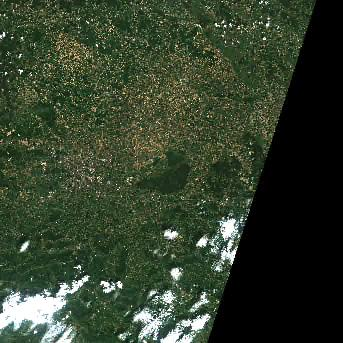

In [17]:
if LIVE_READY:
    with connect_db(DB_PATH) as conn:
        candidates = conn.execute("""SELECT * FROM scenes WHERE collection=?
            ORDER BY cloud_cover IS NULL, cloud_cover, acquired_at""", (COLLECTION,)).fetchall()
        choice = next((row for row in candidates
                       if 'thumbnail' in json.loads(row['assets_json'])
                       and json.loads(row['assets_json'])['thumbnail'].get('type') == 'image/jpeg'
                       and json.loads(row['assets_json'])['thumbnail']['href'].startswith('https://')), None)
        if choice is None:
            print('No public HTTPS thumbnail found. Inspect item assets; do not assume a fixed asset set.')
        else:
            # One invocation, one scene, one JPEG. No asset queue or imagery loop.
            saved = download_asset(conn, choice['collection'], choice['item_id'], 'thumbnail', ROOT / 'downloads')
            print('Preview saved:', saved)
            print('Download record:', dict(conn.execute('SELECT * FROM downloads WHERE collection=? AND item_id=? AND asset_key=?',
                                                       (choice['collection'], choice['item_id'], 'thumbnail')).fetchone()))
            # Display is optional; the actual pipeline code does not depend on IPython.
            try:
                from IPython.display import Image, display
                display(Image(filename=str(saved)))
            except ImportError:
                print('Open the file in an image viewer.')
else:
    print('Preview transfer waits for successful live discovery.')


### Next lab: scientific assets

Inspect the selected item's `red` asset metadata without downloading it. Which format, spatial resolution and source location are listed? What would a processing stage need in addition to the JPEG?

Later labs can add a separate scientific asset downloader or read spatial windows with rasterio. This notebook intentionally permits only a JPEG thumbnail; there is no full band download extension here. Reflectance scale and offset, masks, CRS and pixel grid will belong to scientific processing.


## 5. Containers: introduce the idea now, run the exercise later

A container bundles a service and its dependencies. It does not replace the persistent database or data directory. In this lab, reproducible function boundaries, configuration and external state are the groundwork for a later container.

You can run `!docker ...` from a notebook **if** Docker is already installed and the kernel can access its daemon. The container runs under that external daemon; it is not contained within the notebook. Docker installation, permissions and mounts often consume an introductory lab, particularly on Windows. Keep them out of the graded core today.

In the next lab, move your tested functions into `discover.py`, add command line arguments and a small dependency file, and run it from a terminal. Then package that script. Keep the database and downloads on a mounted directory. Restarting the container must retain them. Gaia's supported runtime will determine whether you use Docker, Apptainer or another option; ask its administrators before designing the cluster submission.

Illustrative Dockerfile for that later script (not runnable with this notebook alone):

```dockerfile
FROM python:3.12-slim
WORKDIR /app
COPY discover.py .
ENTRYPOINT ["python", "discover.py"]
```

The stdlib implementation needs no pip dependencies. Pin the image digest when publishing a reproducible version. Example build command, after creating the script and Dockerfile: `docker build -t sentinel-discovery:lab2 .`

Example PowerShell launch, after `discover.py` supports these arguments: `docker run --rm --mount "type=bind,source=$($PWD.Path)/sentinel_lab1,target=/data" sentinel-discovery:lab2 --db /data/catalogue.sqlite --download-dir /data/downloads`

Example Bash launch: `docker run --rm --mount "type=bind,source=$(pwd)/sentinel_lab1,target=/data" sentinel-discovery:lab2 --db /data/catalogue.sqlite --download-dir /data/downloads`

These examples are for a future extracted script, not a first lab prerequisite.


## 6. Submission and light grading

Submit the repaired notebook with check outputs, a sketch of the three table relationships, and a short explanation beside each repair. Do not submit downloaded imagery or credentials.

| Component | Points |
|---|---:|
| Database repair and relationship explanation | 4 |
| Pagination repair and completion explanation | 2 |
| Discovery overlap, recovery and progress explanation | 3 |
| Clear evidence from checks and downloader discussion | 1 |

Passing tests is evidence of behaviour, not a complete design review. Explain why the repaired code is safer and identify one remaining limitation. The checks using captured real catalog records and JPEG bytes are the grading baseline. Include the live summary and displayed preview when the network is available. Network availability does not determine your grade.

Extensions are optional: a query run history table, a separate source asset table, POST pagination, periodic full reconciliation, or an extracted command line service. None is required for this lab.


## Sources and scope checked 5 October 2026

- [Earth Search documentation](https://github.com/Element84/earth-search/blob/main/README.md): collections, public HTTPS versus requester pays S3 assets, and service scope.
- [STAC API Item Search specification](https://github.com/radiantearth/stac-api-spec/blob/release/v1.0.0/item-search/README.md): item searches, next links and GET/POST pagination.
- [Earth Search examples](https://element84.com/earth-search/examples/).
- [Python sqlite3 documentation](https://docs.python.org/3/library/sqlite3.html): parameters and transaction behaviour.
- [Python os.replace documentation](https://docs.python.org/3/library/os.html#os.replace): file replacement; the `.part` file is kept on the same filesystem as its destination.

This is a teaching service for a small query and one process. It does not implement catalogue snapshots, multiworker locking, full provenance, automatic remote object version checks, authoritative provider checksum validation, credential refresh, or arbitrary late arrival recovery.


Real data snapshot: Earth Search Sentinel 2 L2A, Kraków bbox `[19.7, 49.9, 20.1, 50.2]`, acquisition interval 1–15 June 2025, captured 5 October 2026. All 16 items and provider pagination envelopes are embedded unchanged. Preview source and SHA-256 are recorded in the data cell. Packaging compression is lossless.
